# Iterative Imputation
Iterative Imputation (also known as **Multivariate Imputation by Chain Equations - MICE** or **Fully Conditional Specification**) is an advanced missing data imputation technique that models each feature with missing values as a function of other features in a round-robin fashion

---
## The Core Concept
**How it works**:
1. Initialize missing values with simple imputation (e.g., mean/median)
2. For each feature with missing values:
   * Use other features as predictors to build a model
   * Predict missing values for that features
3. Repeat (iterate) this process multiple times
4. Each iteration improves the estimates  
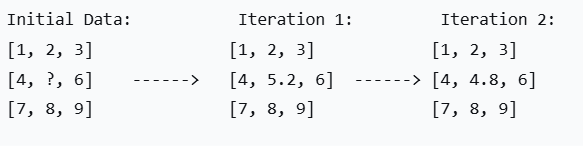

---
## Key Parameters
|**Parameter**|**Description**|**Typical Values**|
|-------------|---------------|------------------|
|**estimator**|The regression/classification model to use|BayesianRidge, RandomForest, LinearRegression|
|**max_iter**|Maximum number of imputation rounds|10, 20, 50|
|**tol**|Convergence tolerance|1e-3, 1e-2|
|**initial_strategy**|Initial imputation method|'mean', 'median', 'most_frequent'|
|**sample_posterior**|Add noise to imputations|True/False|

---
## Advantages & Disadvantages
|**Pros**|**Cons**|
|--------|--------|
|✅Preserves relationships between variables|❌Computationally expensive (especially with large datasets)|
|✅Handles multiple missing patterns|❌Sensitivity to initial imputation vlues|
|✅Uses information form all features|❌Can be unstable with high colinearity|
|✅Often more accurate than other simpler methods|❌Requires careful parameter tuining|
|✅Can handle mixed data types|❌More complex to implement|

---
## When to Use Iterative Imputation
**Best for**:
* Datasets with complex relationships between features
* Multiple features with missing values
* MAR data
* When accuracy is critical
* Moderate dataset sizes (< 50k rows)

**Avoid when**:
* Dataset is extremely large (> 100k rows)
* Missing rate is very high (> 50%)
* Feature relationships are weak or unknown
* Speed is more important than accuracy
---

In [1]:
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.linear_model import BayesianRidge, LinearRegression

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Sample data with missing values
data = pd.DataFrame({
    'Age': [25, 47, np.nan, 35, 22],
    'Salary': [50000, 95000, 80000, np.nan, 45000],
    'Experience': [1, 15, 10, 7, 0]
})
data

,Age,Salary,Experience
0,25.0,50000.0,1
1,47.0,95000.0,15
2,NaN,80000.0,10
3,35.0,NaN,7
4,22.0,45000.0,0


In [3]:
# Run the imputer
imputer = IterativeImputer(estimator = BayesianRidge(), max_iter = 10, tol = 1e-3, initial_strategy = 'mean', random_state = 42)
imputer.set_output(transform = 'pandas')

imputed_data = imputer.fit_transform(data)
imputed_data

,Age,Salary,Experience
0,25.000000,50000.000000,1.0
1,47.000000,95000.000000,15.0
2,39.671306,80000.000000,10.0
3,35.000000,70229.457476,7.0
4,22.000000,45000.000000,0.0


In [4]:
df = np.round(pd.read_csv('50_Startups.csv')[['R&D Spend','Administration','Marketing Spend','Profit']]/10000)
np.random.seed(9)
df = df.sample(5)
df

,R&D Spend,Administration,Marketing Spend,Profit
21,8.0,15.0,30.0,11.0
37,4.0,5.0,20.0,9.0
2,15.0,10.0,41.0,19.0
14,12.0,16.0,26.0,13.0
44,2.0,15.0,3.0,7.0


In [5]:
df = df.iloc[:, 0:-1]
df

,R&D Spend,Administration,Marketing Spend
21,8.0,15.0,30.0
37,4.0,5.0,20.0
2,15.0,10.0,41.0
14,12.0,16.0,26.0
44,2.0,15.0,3.0


In [6]:
# Introducing missing values
df.iloc[1,0] = np.nan
df.iloc[3,1] = np.nan
df.iloc[-1,-1] = np.nan

In [7]:
df.head()

,R&D Spend,Administration,Marketing Spend
21,8.0,15.0,30.0
37,NaN,5.0,20.0
2,15.0,10.0,41.0
14,12.0,NaN,26.0
44,2.0,15.0,NaN


In [8]:
# Step 1 = Impute all missing values with mean of respective column
df0 = pd.DataFrame()
df0['R&D Spend'] = df['R&D Spend'].fillna(df['R&D Spend'].mean())
df0['Administration'] = df['Administration'].fillna(df['Administration'].mean())
df0['Marketing Spend'] = df['Marketing Spend'].fillna(df['Marketing Spend'].mean())

df0

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,9.25,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.25,26.00
44,2.00,15.00,29.25


In [9]:
# For each feature with missing values:
# Use other features as predictors to build a model
# Predict missing values for that features
df1 = df0.copy()
df1.iloc[1,0] = np.nan
df1

,R&D Spend,Administration,Marketing Spend
21,8.0,15.00,30.00
37,NaN,5.00,20.00
2,15.0,10.00,41.00
14,12.0,11.25,26.00
44,2.0,15.00,29.25


In [10]:
X = df1.iloc[[0,2,3,4], 1:3]
y = df1.iloc[[0,2,3,4],0]

In [11]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(df1.iloc[1,1:].values.reshape(1,2))
y_pred

array([23.14158651])

In [12]:
df1.iloc[1, 0] = y_pred.round(2)
df1

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.14,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.25,26.00
44,2.00,15.00,29.25


In [14]:
df1.iloc[3,1] = np.nan
df1

,R&D Spend,Administration,Marketing Spend
21,8.00,15.0,30.00
37,23.14,5.0,20.00
2,15.00,10.0,41.00
14,12.00,NaN,26.00
44,2.00,15.0,29.25


In [15]:
X = df1.iloc[[0, 1,2, 4],[0, 2]]
y = df1.iloc[[0, 1, 2, 4], 1]

In [16]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(df1.iloc[3,[0, 2]].values.reshape(1,2))
y_pred

array([11.06331285])

In [17]:
df1.iloc[3, 1] = y_pred.round(2)
df1

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.14,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.06,26.00
44,2.00,15.00,29.25


In [19]:
df1.iloc[4,-1] = np.nan
df1

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.0
37,23.14,5.00,20.0
2,15.00,10.00,41.0
14,12.00,11.06,26.0
44,2.00,15.00,NaN


In [20]:
X = df1.iloc[0:4,0:2]
y = df1.iloc[0:4, -1]

In [21]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(df1.iloc[-1,0:2].values.reshape(1,2))
y_pred

array([31.56351448])

In [23]:
df1.iloc[-1, -1] = y_pred.round(2)
df1

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.14,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.06,26.00
44,2.00,15.00,31.56


In [24]:
# Now subtract the source df from the resultant df
df1 - df0

,R&D Spend,Administration,Marketing Spend
21,0.00,0.00,0.00
37,13.89,0.00,0.00
2,0.00,0.00,0.00
14,0.00,-0.19,0.00
44,0.00,0.00,2.31


In [25]:
# Now the df1 is our new source
df2 = df1.copy()
df2

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.14,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.06,26.00
44,2.00,15.00,31.56


In [26]:
df2.iloc[1,0] = np.nan
df2

,R&D Spend,Administration,Marketing Spend
21,8.0,15.00,30.00
37,NaN,5.00,20.00
2,15.0,10.00,41.00
14,12.0,11.06,26.00
44,2.0,15.00,31.56


In [27]:
X = df2.iloc[[0,2,3,4], 1:]
y = df2.iloc[[0,2,3,4], 0]

lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(df2.iloc[1, 1:].values.reshape(1,2))
y_pred

array([23.78627207])

In [28]:
df2.iloc[1,0] = y_pred.round(2)
df2

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.79,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.06,26.00
44,2.00,15.00,31.56


In [30]:
df2.iloc[3, 1] = np.nan
df2

,R&D Spend,Administration,Marketing Spend
21,8.00,15.0,30.00
37,23.79,5.0,20.00
2,15.00,10.0,41.00
14,12.00,NaN,26.00
44,2.00,15.0,31.56


In [31]:
X = df2.iloc[[0, 1,2, 4], [0, -1]]
y = df2.iloc[[0, 1, 2, 4], 1]
test = df2.iloc[3, [0,-1]]

In [33]:

lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(test.values.reshape(1, 2))
y_pred

array([11.22217647])

In [34]:
df2.iloc[3, 1] = y_pred.round(2)
df2

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.79,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.22,26.00
44,2.00,15.00,31.56


In [35]:
df2.iloc[-1, -1] = np.nan
df2

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.0
37,23.79,5.00,20.0
2,15.00,10.00,41.0
14,12.00,11.22,26.0
44,2.00,15.00,NaN


In [40]:
X = df2.iloc[0:-1, 0:2]
y = df2.iloc[0:-1, -1]
test = df2.iloc[-1, 0:2]

In [41]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(test.values.reshape(1, 2))
y_pred

array([38.94316424])

In [42]:
df2.iloc[-1, -1] = y_pred.round(2)
df2

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.79,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.22,26.00
44,2.00,15.00,38.94


In [44]:
df2 - df1

,R&D Spend,Administration,Marketing Spend
21,0.00,0.00,0.00
37,0.65,0.00,0.00
2,0.00,0.00,0.00
14,0.00,0.16,0.00
44,0.00,0.00,7.38


In [47]:
df3 = df2.copy()
df3

,R&D Spend,Administration,Marketing Spend
21,8.00,15.00,30.00
37,23.79,5.00,20.00
2,15.00,10.00,41.00
14,12.00,11.22,26.00
44,2.00,15.00,38.94


In [50]:
df

,R&D Spend,Administration,Marketing Spend
21,8.0,15.0,30.0
37,NaN,5.0,20.0
2,15.0,10.0,41.0
14,12.0,NaN,26.0
44,2.0,15.0,NaN


In [72]:
df

,R&D Spend,Administration,Marketing Spend
21,8.0,15.0,30.0
37,NaN,5.0,20.0
2,15.0,10.0,41.0
14,12.0,NaN,26.0
44,2.0,15.0,NaN


In [76]:
def iterative_imputation(df, max_iter = 10):
    df_imputed = df.copy()

    # Initial mean imputation
    for col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mean())

    # Original missing value locations
    missing_mask = df.isnull()
    for iteration in range(max_iter):
        previous = df_imputed.copy()

        for target_col in df.columns:
            missing_rows = missing_mask[target_col]

            if not missing_rows.any():
                continue

            feature_cols = [
                col for col in df.columns
                if col != target_col
            ]

            # Trainig data
            X_train = df_imputed.loc[~missing_rows, feature_cols]
            y_train = df_imputed.loc[~missing_rows, target_col]


            # Rows requiring prediction
            X_pred = df_imputed.loc[missing_rows, feature_cols]

            model = LinearRegression()
            model.fit(X_train, y_train)

            predictions = model.predict(X_pred)

            df_imputed.loc[missing_rows, target_col] = predictions

        # Convergence check
        change = np.abs(df_imputed - previous).max().max()

        print(f"Itration {iteration + 1}: change = {change:.6f}")

        if change < 1e-5:
            break
    return df_imputed

In [77]:
result = iterative_imputation(df, max_iter = 10)
result

Itration 1: change = 13.891587
Itration 2: change = 7.788589
Itration 3: change = 23.948920
Itration 4: change = 7.612848
Itration 5: change = 0.272354
Itration 6: change = 0.012787
Itration 7: change = 0.000597
Itration 8: change = 0.000028
Itration 9: change = 0.000001


,R&D Spend,Administration,Marketing Spend
21,8.000000,15.000000,30.000000
37,26.718364,5.000000,20.000000
2,15.000000,10.000000,41.000000
14,12.000000,13.022368,26.000000
44,2.000000,15.000000,70.692067


### Using Sklearn

In [78]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [79]:
imputer = IterativeImputer(
    estimator = LinearRegression(),
    max_iter = 10,
    random_state = 42
)
imputer.set_output(transform = 'pandas')

IterativeImputer(estimator=LinearRegression(), random_state=42)

In [80]:
df_imputed = imputer.fit_transform(df)
df_imputed

,R&D Spend,Administration,Marketing Spend
21,8.000000,15.000000,30.000000
37,26.718225,5.000000,20.000000
2,15.000000,10.000000,41.000000
14,12.000000,13.022458,26.000000
44,2.000000,15.000000,70.692637
